In [486]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import RegularGridInterpolator

In [487]:
df = pd.read_csv('VOO IV Surface df.csv')
K = df['Strike'].to_numpy() # test log moneyness instead of strike and change K first and last to min and max
T = df['TTM'].to_numpy() 
y = df['Price'].to_numpy() 

In [488]:
y_mesh = y.reshape((8,8)) # needed for bicubic interpolation
print(y_mesh.shape) # rows are maturities and col are strikes

(8, 8)


In [489]:
'''
Get vectors of strikes and TTM for interpolation
'''
# get first and last value in columns of Strikes and TTM
K_min = np.min(K)
K_max = np.max(K)

T_min = np.min(T)
T_max = np.max(T)

# get gap size in interpolation vector
n_K = int((K_max - K_min)/0.1)
n_T = int((T_max - T_min)/0.002739) # if 1 represents 1 year, then 1/365 ≈ 0.00273973

# get np vector
K_grid = np.linspace(K_min, K_max, 700)
T_grid = np.linspace(T_min, T_max, 700)

K_grid = np.round(K_grid, 1)
T_grid = np.round(T_grid, 6)

K_mesh, T_mesh = np.meshgrid(K_grid, T_grid)

#print(K_grid)
print(T_mesh)

[[0.049315 0.049315 0.049315 ... 0.049315 0.049315 0.049315]
 [0.051455 0.051455 0.051455 ... 0.051455 0.051455 0.051455]
 [0.053595 0.053595 0.053595 ... 0.053595 0.053595 0.053595]
 ...
 [1.540925 1.540925 1.540925 ... 1.540925 1.540925 1.540925]
 [1.543065 1.543065 1.543065 ... 1.543065 1.543065 1.543065]
 [1.545205 1.545205 1.545205 ... 1.545205 1.545205 1.545205]]


# Bicubic Interpolation Benchmark

In [490]:
T_unique = np.sort(np.unique(T))
K_unique = np.sort(np.unique(K))

In [491]:
bicubic = RegularGridInterpolator(
    (T_unique, K_unique),
    y_mesh,
    method="cubic"
)

In [492]:
T_new = np.linspace(T_unique.min(), T_unique.max(), 700)
K_new = np.linspace(K_unique.min(), K_unique.max(), 700)

T_grid_new, K_grid_new = np.meshgrid(
    T_new,
    K_new,
    indexing="ij"
)

points = np.column_stack([
    T_grid_new.ravel(),
    K_grid_new.ravel()
])

y_bicubic = bicubic(points).reshape(700, 700)

In [536]:
print(y_bicubic.shape)

(700, 700)


### Performance Metrics Calculation and Price Surface

In [501]:
def evaluate_surface(C_true, C_fit, C_pred, K, T):
    
    y_true = np.asarray(C_true)
    y_fit = np.asarray(C_fit)
    C_pred = np.asarray(C_pred)
    num_pred = len(C_pred.flatten())
    K = np.asarray(K)
    T = np.asarray(T)

    # ------------------------------------------------
    # Prediction metrics
    # ------------------------------------------------

    y_true = C_true.flatten()
    y_fit = C_fit.flatten()

    mae = np.mean(np.abs(y_true - y_fit))

    ss_res = np.sum((y_true - y_fit)**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)

    r2 = 1 - ss_res / ss_tot

    # Mean relative error
    mask = y_true != 0

    mre = np.mean(
        np.abs(
            (y_true[mask] - y_fit[mask])
            / y_true[mask]
        )
    )

    # ------------------------------------------------
    # Butterfly violations
    # ------------------------------------------------

    dK = K_grid[1] - K_grid[0]

    d2C_dK2 = (
        C_pred[:, 2:]
        - 2 * C_pred[:, 1:-1]
        + C_pred[:, :-2]
    ) / dK**2
    
    violating_points_but = d2C_dK2[d2C_dK2 < 0]
    max_violation_mag_but = -np.max(violating_points_but)

    num_but_violations = np.sum(d2C_dK2 < 0)
    mean_but_violations = np.mean(violating_points_but)
    but_violations_prop = num_but_violations / num_pred
    
    # Calendar Arbitrage
    dT = T_grid[1] - T_grid[0]
    
    dC_dT = (
        C_pred[2:, :]
        - C_pred[:-2, :]
    ) / (2 * dT)

    violating_points_cal = dC_dT[dC_dT < 0]
    max_violation_mag_cal = -np.max(violating_points_cal)

    num_cal_violations = np.sum(dC_dT < 0)
    mean_cal_violations = np.mean(violating_points_cal)
    cal_violations_prop = num_cal_violations / num_pred
    
    # ------------------------------------------------
    # Smoothness
    # ------------------------------------------------
    d2C_dT2 = (
        C_pred[2:, :]
        - 2 * C_pred[1:-1, :]
        + C_pred[:-2, :]
    ) / dT**2
    
    strike_smoothness = np.mean(
        d2C_dK2**2
    )

    maturity_smoothness = np.mean(
        d2C_dT2**2
    )

    # ------------------------------------------------
    # Results
    # ------------------------------------------------

    return {
        "MAE": mae,
        "R2": r2,
        "Mean Relative Error": mre,
        "Number of Butterfly Violations" : num_but_violations,
        "Number of Calendar Violations" : num_cal_violations,
        "Proportion of Butterfly Violations" : but_violations_prop,
        "Proportion of Calendar Violations" : cal_violations_prop,
        "Max Butterfly Violation": max_violation_mag_but,
        "Max Calendar Violation": max_violation_mag_cal,
        "Strike Smoothness": strike_smoothness,
        "Maturity Smoothness": maturity_smoothness
    }

In [543]:
results = []

result_dict_bicubic = evaluate_surface(
    y, y, y_bicubic, K_grid, T_grid
)

result_dict_bicubic["Model"] = "Bicubic Interpolation"

results.append(result_dict_bicubic)
print(results)

[{'MAE': np.float64(0.0), 'R2': np.float64(1.0), 'Mean Relative Error': np.float64(0.0), 'Number of Butterfly Violations': np.int64(256895), 'Number of Calendar Violations': np.int64(64662), 'Proportion of Butterfly Violations': np.float64(0.5242755102040816), 'Proportion of Calendar Violations': np.float64(0.13196326530612246), 'Max Butterfly Violation': np.float64(6.059508450559379e-09), 'Max Calendar Violation': np.float64(0.0003323175703465312), 'Strike Smoothness': np.float64(0.0019257177855686873), 'Maturity Smoothness': np.float64(119248.79554489024), 'Model': 'Bicubic Interpolation'}]


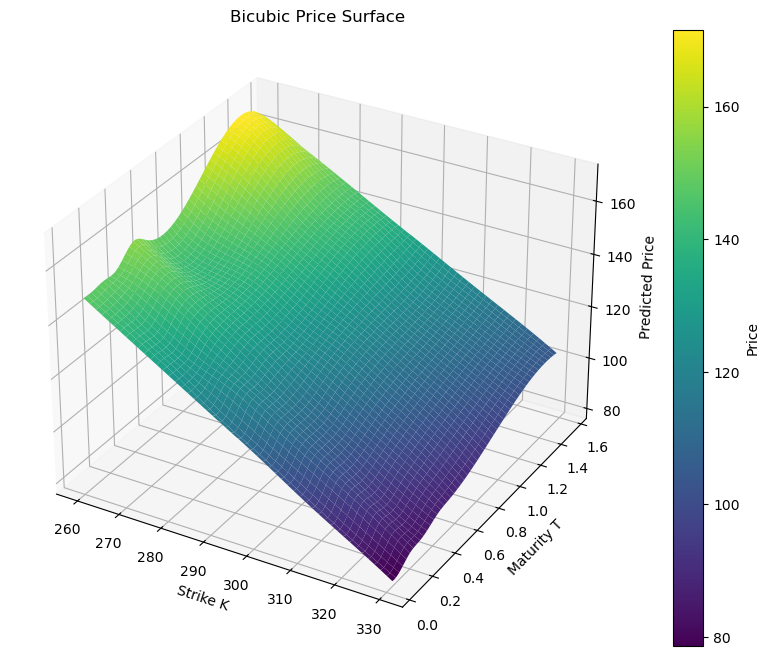

In [567]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(
    K_mesh,
    T_mesh,
    y_bicubic,
    cmap='viridis',
    edgecolor='none'
)

ax.set_xlabel('Strike K')
ax.set_ylabel('Maturity T')
ax.set_zlabel('Predicted Price')
ax.set_title('Bicubic Price Surface')

fig.colorbar(surf, ax=ax, label='Price')

# 2. Save the graph to a PNG file (Call this BEFORE plt.show())
plt.savefig('bicubic surface.png')

# 3. Display the graph on screen (Optional)
plt.show()

# Ordinary B-Spline Regression

In [495]:
import numpy as np
from sklearn.preprocessing import SplineTransformer
from sklearn.linear_model import LinearRegression

### Observe Spline and Matrix Outer Product

In [496]:
K = df['Strike'].to_numpy()
T = df['TTM'].to_numpy()

spline = SplineTransformer(
        n_knots = 8,
        degree = 3,
        knots = "quantile",
        include_bias = False
    )

spline1 = spline.fit_transform(K.reshape(-1,1))
spline2 = spline.fit_transform(T.reshape(-1,1))

test = np.einsum("ij,ik->ijk", spline1, spline2)
test = test.reshape(len(K), -1)
print(K.shape)
print(test)

(64,)
[[0.02777778 0.11111123 0.02777766 ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 ...
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.03048779 0.10840109]
 [0.         0.         0.         ... 0.         0.12195118 0.43360438]]


### B-Spline Regression Function

In [497]:
def bspline_regression(df, n_knots_K, n_knots_T, degree):
    '''
    df: DataFrame with column names 'Strike', 'TTM' (Time to Maturity), and 'IV'
    '''
    # retrieve K, T, and response variable y
    K = df['Strike'].to_numpy()
    T = df['TTM'].to_numpy()
    y = df['Price'].to_numpy()
    
    # Create marginal B-spline bases
    spline_K = SplineTransformer(
        n_knots = n_knots_K,
        degree = degree,
        knots = "quantile",
        include_bias = False
    )

    spline_T = SplineTransformer(
        n_knots = n_knots_T,
        degree = degree,
        knots = "quantile",
        include_bias = False
    )

    B_K = spline_K.fit_transform(K.reshape(-1, 1)) # reshape(-1,1) makes matrix with arbitrary rows and 1 column, i.e. a column vector
    B_T = spline_T.fit_transform(T.reshape(-1, 1)) # sklearn fit_transform only takes 2D arrays ^

    # Tensor-product basis
    '''
    Evaluates Einstein summation notation on multi-dim arrays, like outer product uv^T = nxn matrix of products of u_i v_j components.
    "ij,ik->ijk" calculates the outer product of two matrices along the rows of both matrices resulting in 3 dim tensor.
    Out[i,j,k] = A[i,j] x B[i,k]
    '''
    B = np.einsum("ij,ik->ijk", B_K, B_T)
    B = B.reshape(len(K), -1) # converts z-axis of 3D matrix and converts it into more columns for matrix (64,9,9) -> (64,81)

    # Ordinary least squares
    model = LinearRegression()
    model.fit(B, y)

    # get model coefficients (betas)
    temp_coef = model.coef_
    coef = np.insert(temp_coef, 0, model.intercept_)
    
    # get hat matrix
    H = B@np.linalg.solve(B.T@B, B.T)
    
    return model, spline_K, spline_T, coef, H 


def convert_bspline_matrix(K_new, T_new, n_knots_K, n_knots_T, degree):
    spline_K = SplineTransformer(
        n_knots = n_knots_K,
        degree = degree,
        knots = "quantile",
        include_bias = False
    )

    spline_T = SplineTransformer(
        n_knots = n_knots_T,
        degree = degree,
        knots = "quantile",
        include_bias = False
    )
    
    B_K_new = spline_K.fit_transform(K_new.reshape(-1, 1))
    B_T_new = spline_T.fit_transform(T_new.reshape(-1, 1))

    B_new = np.einsum(
        "ij,ik->ijk",
        B_K_new,
        B_T_new
    ).reshape(len(K_new), -1)

    return B_new

In [498]:
knot_vals = [2,3,4,5,6,7]
loo_results = []

for knot_k in knot_vals:
    for knot_t in knot_vals:
        model, spline_K, spline_T, coefficients, H = bspline_regression(
            df=df,
            n_knots_K=knot_k,
            n_knots_T=knot_t,
            degree=3
        )
    
        B_old = convert_bspline_matrix(K, T, knot_k, knot_t, 3)
        B_new = convert_bspline_matrix(K_mesh.ravel(), T_mesh.ravel(), knot_k, knot_t, 3)
    
        y_hat = model.predict(B_old)
    
        residuals = y - y_hat
    
        # Avoid saturated models
        if np.max(np.diag(H)) >= 0.999:
            continue
    
        loo_residuals = (
            residuals /
            (1 - np.diag(H))
        )

        loo_rmse = np.sqrt(
            np.mean(loo_residuals**2)
        )

        loo_results.append(
            (knot_k, knot_t, loo_rmse)
        )

best = min(loo_results, key=lambda x: x[2])

print("Best K knots:", best[0])
print("Best T knots:", best[1])
print("LOOCV RMSE:", best[2])


Best K knots: 2
Best T knots: 7
LOOCV RMSE: 1.0616163492726147


In [499]:
model, spline_K, spline_T, coefficients, H = bspline_regression(
    df=df,
    n_knots_K=2,
    n_knots_T=7,
    degree=3
)
    
B_old = convert_bspline_matrix(K, T, 2, 7, 3)
B_new = convert_bspline_matrix(K_mesh.ravel(), T_mesh.ravel(), 2, 7, 3)

y_hat_bspline = model.predict(B_old)
y_hat_bspline = y_hat_bspline.reshape((8,8))

pred_bspline = model.predict(B_new)
pred_bspline = pred_bspline.reshape(K_mesh.shape)

print(y_hat_bspline.shape)

(8, 8)


### Performance Metrics Calculations and Price Surface

In [500]:
print("B shape:", B_old.shape)
print("Rank:", np.linalg.matrix_rank(B_old))
print("Hat matrix DF:", np.trace(H))
print("Min Hii:", np.min(np.diag(H)))
print("Max Hii:", np.max(np.diag(H)))

B shape: (64, 24)
Rank: 24
Hat matrix DF: 23.999999999999602
Min Hii: 0.20876863139678778
Max Hii: 0.8123602297689025


In [544]:
result_dict_bspline = evaluate_surface(
    y, y_hat_bspline, pred_bspline, K_grid, T_grid
)

result_dict_bspline["Model"] = "B-spline"

results.append(result_dict_bspline)

#result_df = pd.DataFrame(results)
#result_df.head()

In [503]:
# Butterly Arbitrage
dK = K_grid[1] - K_grid[0]

d2C_dK2 = (
    price_pred[:, 2:]
    - 2 * price_pred[:, 1:-1]
    + price_pred[:, :-2]
) / dK**2

num_butterfly_violations = np.sum(d2C_dK2 < 0)
print(f'Number of Butterfly Arbitrage Violations: {num_butterfly_violations}')

violating_points = d2C_dK2[d2C_dK2 < 0]
max_violation_mag = -np.max(violating_points)
print(max_violation_mag)

# Calendar Arbitrage
dT = T_grid[1] - T_grid[0]

dC_dT = (
    price_pred[2:, :]
    - price_pred[:-2, :]
) / (2 * dT)

num_cal_violations = np.sum(dC_dT < 0)
print(f'Number of Calendary Arbitrage Violations: {num_cal_violations}')

Number of Butterfly Arbitrage Violations: 337439
3.661000391728675e-08
Number of Calendary Arbitrage Violations: 94154


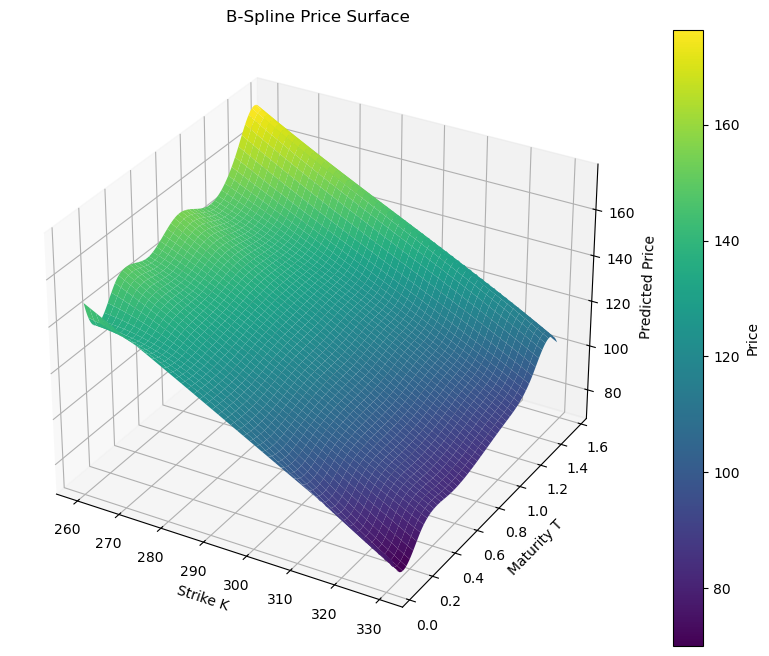

In [568]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(
    K_mesh,
    T_mesh,
    pred_bspline,
    cmap='viridis',
    edgecolor='none'
)

ax.set_xlabel('Strike K')
ax.set_ylabel('Maturity T')
ax.set_zlabel('Predicted Price')
ax.set_title('B-Spline Price Surface')

fig.colorbar(surf, ax=ax, label='Price')

# 2. Save the graph to a PNG file (Call this BEFORE plt.show())
plt.savefig('b-spline surface.png')

# 3. Display the graph on screen (Optional)
plt.show()

# P-Splines (Penalized B-Splines)

In [505]:
def p_spline_regression_betas(df, n_knots_K, n_knots_T, degree, lam):
    '''
    returns estiamted betas, hat matrix, and 2nd order penalty matrix
    '''
    # retrieve K, T, and response variable y
    K = df['Strike'].to_numpy()
    T = df['TTM'].to_numpy()
    y = df['Price'].to_numpy()
    
    B = convert_bspline_matrix(K, T, n_knots_K, n_knots_T, degree)
    p = B.shape[1]

    D2 = np.zeros(((p - 2), p))
    for j in range(p - 2):
        D2[j, j] = 1
        D2[j, j+1] = -2
        D2[j, j+2] = 1

    beta_hat = np.linalg.solve(
        B.T@B + lam * D2.T@D2, B.T@y
    )

    hat_matrix = B@np.linalg.solve(B.T@B + lam * D2.T@D2, B.T)

    return beta_hat, hat_matrix, D2

### Test P-Spline Fit Output

In [587]:
# GCV error to find optimal lambda
# B@beta_hat to predict
# B_new is the strike and TTM grid for interpolation
n_knots_K=7
n_knots_T=9 # lowest gcv from 5 - 10 combinations for each

pspline_betas, pspline_hat_matrix, D2 = p_spline_regression_betas(
    df=df,
    n_knots_K=n_knots_K,
    n_knots_T=n_knots_T,
    degree=3,
    lam = 1
)

B_old = convert_bspline_matrix(K, T, n_knots_K, n_knots_T, 3)
B_new = convert_bspline_matrix(K_mesh.ravel(), T_mesh.ravel(), n_knots_K, n_knots_T, 3)

pspline_pred = B_new @ pspline_betas
pspline_pred = pspline_pred.reshape(K_mesh.shape)

print(pspline_pred.shape)
#print(D2)

(700, 700)


### Tune Lambda Penalty 

In [507]:
def gcv_score_pspline(B, y, S, lam):
    n = len(y)
    P = S.T @ S
    A = B.T @ B + lam * P
    
    beta_hat = np.linalg.solve(A, B.T@y)

    hat_matrix = B@np.linalg.solve(A, B.T)

    y_hat = B@beta_hat
    deg_free = np.trace(hat_matrix)

    GCV = (np.sum((y - y_hat)**2)/n) / (1 - deg_free/n)**2
    return GCV, beta_hat, deg_free

In [508]:
def gcv_lam_tune(B, y, S, P_K, P_T, pspline):
    '''
    Inputs: b-spline matrix, response vector y, penalty matrix S
    Outputs: GCV optimized lambda, df, and GCV score associated with best lambda
    '''
    lambdas = np.logspace(-15, 8, 150)
    lambdas_K = np.logspace(-15, 8, 150)
    lambdas_T = np.logspace(-15, 8, 150)
    
    gcv_vals = []
    dfs = []
    lambda_pairs = []
    if pspline == True:
        for lam in lambdas:
            gcv, beta_hat, deg_free = gcv_score_pspline(B, y, S, lam)

            gcv_vals.append(gcv)
            dfs.append(deg_free)

        gcv_vals = np.array(gcv_vals)
        dfs = np.array(dfs)

        best_idx = np.argmin(gcv_vals)
        best_gcv = gcv_vals[best_idx]
        best_lam = lambdas[best_idx]
        best_lam_df = dfs[best_idx]

        print("Best lambda:", best_lam)
        print("GCV:", best_gcv)
        print("Effective df:", best_lam_df)

        return best_lam, best_lam_df, best_gcv, lambdas, gcv_vals, dfs
        
    else:
        for lamk in lambdas_K:
            for lamt in lambdas_T:
                gcv, beta_hat, deg_free = gcv_score_smoothing(B, y, P_K, P_T, lamk, lamt)

                gcv_vals.append(gcv)
                dfs.append(deg_free)
                lambda_pairs.append((lamk, lamt))

        gcv_vals = np.array(gcv_vals)
        dfs = np.array(dfs)

        best_idx = np.argmin(gcv_vals)
        
        best_gcv = gcv_vals[best_idx]
        best_lam_K, best_lam_T = lambda_pairs[best_idx]
        best_lam_df = dfs[best_idx]

        print("Best lambda_K:", best_lam_K)
        print("Best lambda_T:", best_lam_T)
        print("GCV:", best_gcv)
        print("Effective df:", best_lam_df)

        return best_lam_K, best_lam_T, best_lam_df, best_gcv, lambda_pairs, gcv_vals, dfs, best_idx


In [588]:
B = convert_bspline_matrix(K, T, n_knots_K, n_knots_T, 3)
best_lam, best_lam_df, best_gcv, lambdas, gcv_vals, dfs = gcv_lam_tune(B_old, y, D2, None, None, pspline = True)

Best lambda: 0.0002647395290480231
GCV: 1.0958142358254805
Effective df: 56.75472506676271


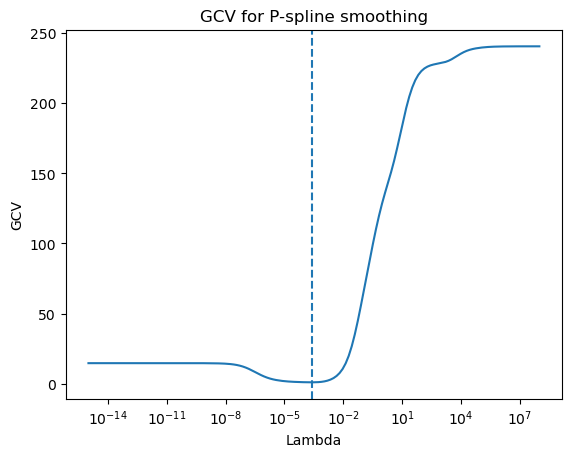

In [573]:
plt.plot(lambdas, gcv_vals)
plt.xscale("log")
plt.xlabel("Lambda")
plt.ylabel("GCV")
plt.title("GCV for P-spline smoothing")
plt.axvline(best_lam, linestyle="--")

plt.savefig('p-spline GCV.png')
plt.show()

General Trend:
- Lower number of knots -> higher lambda, vise versa
- as knots decrease, curvature increases, so larger lambda is chosen to penalize coefficients more harshly as a
  result of more curvature

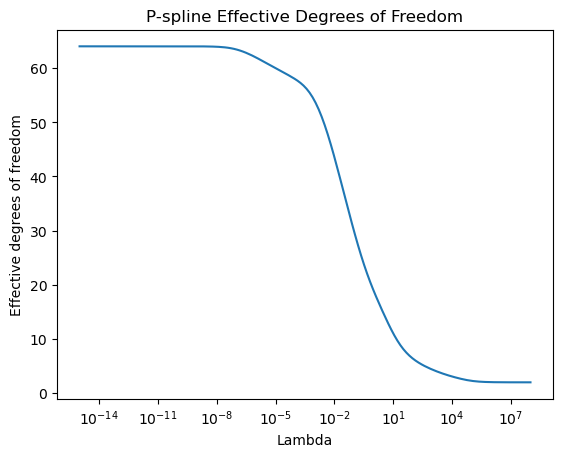

In [589]:
plt.plot(lambdas, dfs)
plt.xscale("log")
plt.xlabel("Lambda")
plt.ylabel("Effective degrees of freedom")
plt.title("P-spline Effective Degrees of Freedom")

plt.savefig('p-spline df.png')
plt.show()

### Fit P-Spline Model and Interpolate

In [528]:
n_knots_K=7
n_knots_T=9 # lowest gcv from 5 - 10 combinations for each

pspline_betas, pspline_hat_matrix, D2 = p_spline_regression_betas(
    df=df,
    n_knots_K=n_knots_K,
    n_knots_T=n_knots_T,
    degree=3,
    lam = best_lam
)

B_old = convert_bspline_matrix(K, T, n_knots_K, n_knots_T, 3)
B_new = convert_bspline_matrix(K_mesh.ravel(), T_mesh.ravel(), n_knots_K, n_knots_T, 3)

y_hat_pspline = B_old @ pspline_betas
y_hat_pspline = y_hat_pspline.reshape((8,8))

pspline_pred = B_new @ pspline_betas
pspline_pred = pspline_pred.reshape(K_mesh.shape)

print(y_hat_pspline.shape)
print(pspline_pred.shape)
#print(D2)

(8, 8)
(700, 700)


### Performance Metrics Calculations and Price Surface

In [545]:
result_dict_pspline = evaluate_surface(
    y, y_hat_pspline, pspline_pred, K_grid, T_grid
)

result_dict_pspline["Model"] = "P-spline"

results.append(result_dict_pspline)

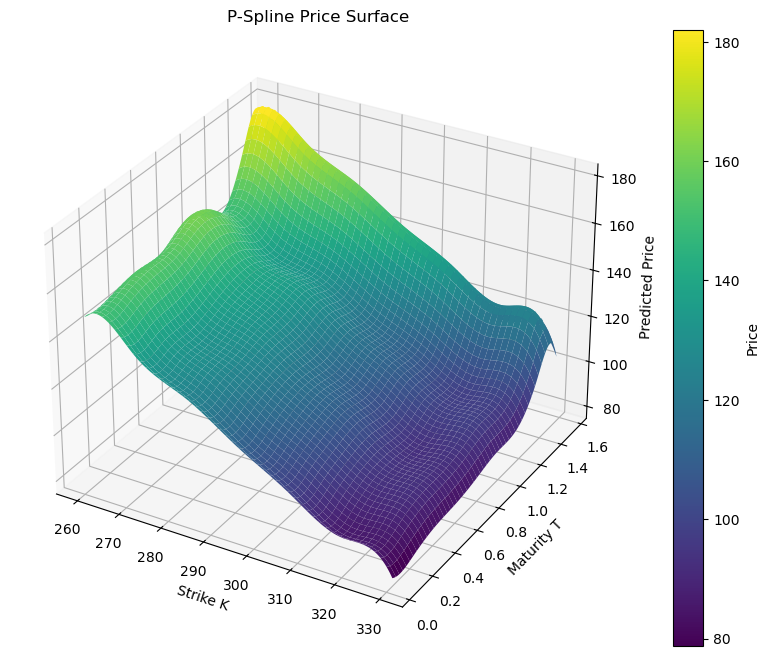

In [569]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(
    K_mesh,
    T_mesh,
    pspline_pred,
    cmap='viridis',
    edgecolor='none'
)

ax.set_xlabel('Strike K')
ax.set_ylabel('Maturity T')
ax.set_zlabel('Predicted Price')
ax.set_title('P-Spline Price Surface')

fig.colorbar(surf, ax=ax, label='Price')

# 2. Save the graph to a PNG file (Call this BEFORE plt.show())
plt.savefig('p-spline surface.png')

# 3. Display the graph on screen (Optional)
plt.show()

# Smoothing Spline Regression

In [514]:
import numpy as np
from scipy.interpolate import BSpline
from numpy.polynomial.legendre import leggauss


def _bspline_knots(x, degree=3):
    """Clamped knot vector using x as internal knots (x must be sorted, unique)."""
    x = np.asarray(x, dtype=float)
    x = np.unique(x)
    return np.r_[[x[0]] * degree, x, [x[-1]] * degree]


def _basis_matrices(x, degree=3, n_quad=50):
    """
    Build S = integral of B_j''(x) B_k''(x) dx  (curvature/penalty matrix)
    and   M = integral of B_j(x)  B_k(x)  dx    (mass matrix)
    for the cubic B-spline basis defined on knots derived from x.
    """
    x = np.unique(np.asarray(x, dtype=float))
    t = _bspline_knots(x, degree)
    n_basis = len(t) - degree - 1

    a, b = x[0], x[-1]

    # Gauss-Legendre quadrature nodes/weights mapped to [a, b]
    nodes, weights = leggauss(n_quad)
    xq = 0.5 * (b - a) * nodes + 0.5 * (b + a)
    wq = 0.5 * (b - a) * weights

    # Evaluate each basis function and its 2nd derivative at quadrature points
    B = np.zeros((n_basis, len(xq)))
    D2B = np.zeros((n_basis, len(xq)))
    for j in range(n_basis):
        c = np.zeros(n_basis)
        c[j] = 1.0
        spl = BSpline(t, c, degree, extrapolate=False)
        d2spl = spl.derivative(2)

        Bj = spl(xq)
        D2j = d2spl(xq)
        B[j] = np.nan_to_num(Bj)
        D2B[j] = np.nan_to_num(D2j)

    # S[j,k] = sum_q wq * D2B_j(xq) * D2B_k(xq)
    S = (D2B * wq) @ D2B.T
    # M[j,k] = sum_q wq * B_j(xq) * B_k(xq)
    M = (B * wq) @ B.T

    return S, M
Ea

def tensor_penalty_matrices(K, T, degree=3, n_quad=50):
    """
    Build tensor-product smoothing-spline penalty matrices S_K*, S_T*
    for f(K,T) = sum_j sum_k beta_jk * B_j(K) * B_k(T), using true
    integrated second-derivative penalties.

    P_K = S_K (x) M_T      penalizes curvature in K
    P_T = M_K (x) S_T      penalizes curvature in T

    beta must be stacked row-major: beta[j*q + k] = beta_jk
    (matches np.kron convention used here).

    Returns
    -------
    P_K, P_T : (p*q, p*q) arrays
    """
    S_K, M_K = _basis_matrices(K, degree, n_quad)
    S_T, M_T = _basis_matrices(T, degree, n_quad)

    P_K = np.kron(S_K, M_T)
    P_T = np.kron(M_K, S_T)

    return P_K, P_T

In [515]:
def smoothing_spline_regression_betas(df, n_knots_K, n_knots_T, degree, lam_K, lam_T):
    '''
    returns estiamted betas and hat matrix
    '''
    # retrieve K, T, and response variable y
    K = df['Strike'].to_numpy()
    T = df['TTM'].to_numpy()
    y = df['Price'].to_numpy()
    
    B = convert_bspline_matrix(K, T, n_knots_K, n_knots_T, degree)
    P_K, P_T = tensor_penalty_matrices(K, T)

    A = B.T @ B + lam_K * P_K + lam_T * P_T
    beta_hat = np.linalg.solve(A, B.T@y)

    hat_matrix = B@np.linalg.solve(A, B.T)

    return beta_hat, hat_matrix

In [516]:
def gcv_score_smoothing(B, y, P_K, P_T, lam_K, lam_T):
    n = len(y)
    A = B.T @ B + lam_K * P_K + lam_T * P_T
    
    beta_hat = np.linalg.solve(A, B.T@y)

    hat_matrix = B@np.linalg.solve(A, B.T)

    y_hat = B@beta_hat
    deg_free = np.trace(hat_matrix)

    GCV = (np.sum((y - y_hat)**2)/n) / (1 - deg_free/n)**2
    return GCV, beta_hat, deg_free

### Testing Model Output Shape

In [577]:
B_old = convert_bspline_matrix(K, T, 9, 9, 3)
B_new = convert_bspline_matrix(K_mesh.ravel(), T_mesh.ravel(), 9, 9, 3)

In [578]:
beta3, _ = smoothing_spline_regression_betas(df, 9, 9, 3, 1, 1)
print(beta3.shape)

(100,)


In [579]:
y_hat2 = B_new @ beta3
print(y_hat2.shape)

(490000,)


### Tune Lambda_K and Lambda_T

In [580]:
P_K, P_T = tensor_penalty_matrices(K,T)
best_lam_K, best_lam_T, best_lam_df, best_gcv, lambda_pairs, gcv_vals, dfs, best_idx = gcv_lam_tune(B_old, y, None, P_K, P_T, False)

Best lambda_K: 1.3412717530678957
Best lambda_T: 7.5717214883374e-06
GCV: 5.861422051571594
Effective df: 52.998057979030534


In [583]:
lambdas_K, lambdas_T = map(list, zip(*lambda_pairs))
indices = [i + 1 for i, j in enumerate(lambda_pairs)]

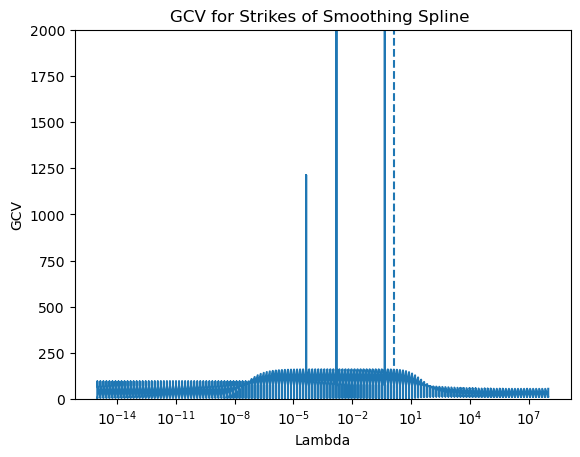

In [584]:
plt.plot(lambdas_K, gcv_vals)
plt.xscale("log")
plt.xlabel("Lambda")
plt.ylabel("GCV")
plt.title("GCV for Strikes of Smoothing Spline ")
plt.axvline(best_lam_K, linestyle="--")
plt.ylim(0, 2000)

plt.savefig('GCV smooth strikes.png')
plt.show()

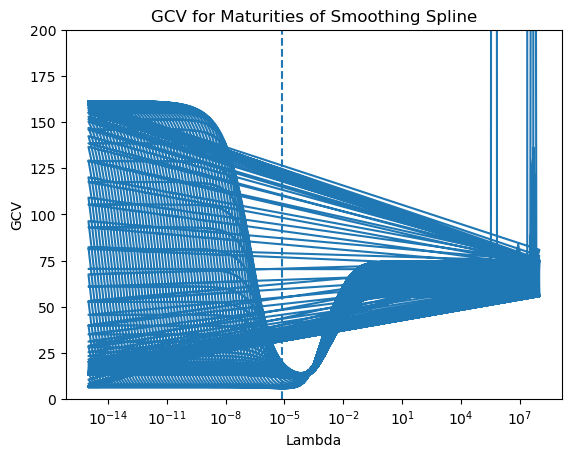

In [585]:
plt.plot(lambdas_T, gcv_vals)
plt.xscale("log")
plt.xlabel("Lambda")
plt.ylabel("GCV")
plt.title("GCV for Maturities of Smoothing Spline")
plt.axvline(best_lam_T, linestyle="--")
plt.ylim(0, 200)

plt.savefig('GCV smooth maturities.png')
plt.show()

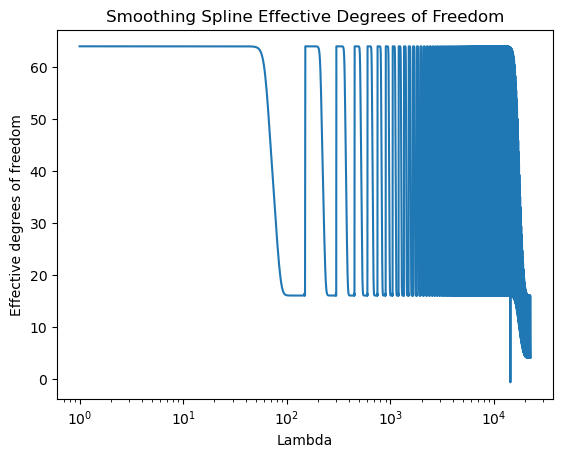

In [586]:
plt.plot(indices, dfs)
plt.xscale("log")
plt.xlabel("Lambda")
plt.ylabel("Effective degrees of freedom")
plt.title("Smoothing Spline Effective Degrees of Freedom")

plt.savefig('smooth df.png')
plt.show()

### Fit Model and Interpolate

In [525]:
n_knots_K=9
n_knots_T=9 # function makes a knot at each x val, ie 9 knots as there are 8 data points per K and T grid

smooth_betas, smooth_hat_matrix = smoothing_spline_regression_betas(
    df=df,
    n_knots_K=n_knots_K,
    n_knots_T=n_knots_T,
    degree=3,
    lam_K=best_lam_K,
    lam_T=best_lam_T
)

B_old = convert_bspline_matrix(K, T, n_knots_K, n_knots_T, 3)
B_new = convert_bspline_matrix(K_mesh.ravel(), T_mesh.ravel(), n_knots_K, n_knots_T, 3)

y_hat_smooth = B_old @ smooth_betas
y_hat_smooth = y_hat_smooth.reshape((8,8))

smooth_pred = B_new @ smooth_betas
smooth_pred = smooth_pred.reshape(K_mesh.shape)

print(y_hat_pspline.shape)
print(pspline_pred.shape)

(8, 8)
(700, 700)


### Performance Metrics Calculations and Price Surface

In [546]:
result_dict_smooth = evaluate_surface(
    y, y_hat_smooth, smooth_pred, K_grid, T_grid
)

result_dict_smooth["Model"] = "Smoothing Spline"

results.append(result_dict_smooth)

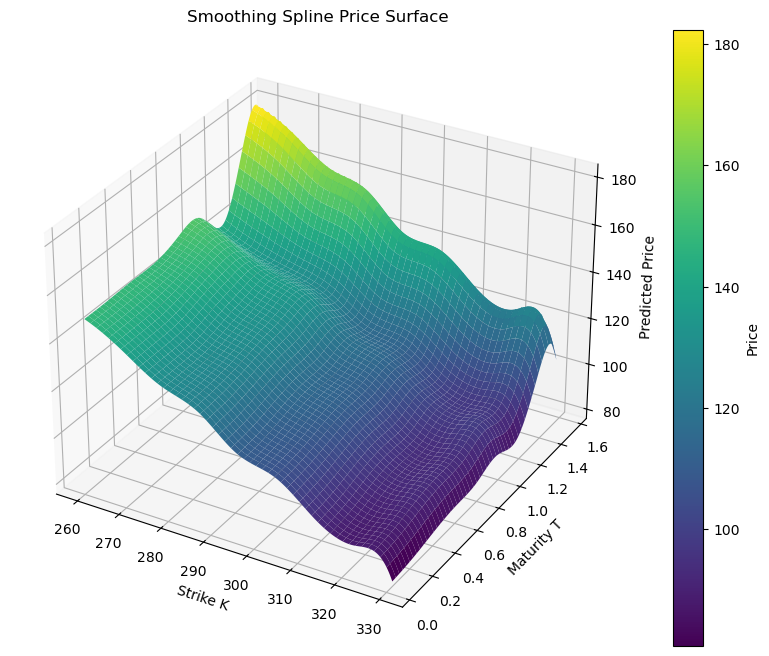

In [570]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(
    K_mesh,
    T_mesh,
    smooth_pred,
    cmap='viridis',
    edgecolor='none'
)

ax.set_xlabel('Strike K')
ax.set_ylabel('Maturity T')
ax.set_zlabel('Predicted Price')
ax.set_title('Smoothing Spline Price Surface')

fig.colorbar(surf, ax=ax, label='Price')

# 2. Save the graph to a PNG file (Call this BEFORE plt.show())
plt.savefig('smoothing spline surface.png')

# 3. Display the graph on screen (Optional)
plt.show()

# Performance Metrics

In [554]:
result_df = pd.DataFrame(results)

In [555]:
cols = list(result_df.columns)
cols = [cols[-1]] + cols[:-1]

# 3. Reassign the reordered columns back to the DataFrame
result_df = result_df[cols]

In [591]:
result_df = result_df.set_index('Model')

In [ ]:
# df.index.name = None

In [592]:
result_df.head()

,MAE,R2,Mean Relative Error,Number of Butterfly Violations,Number of Calendar Violations,Proportion of Butterfly Violations,Proportion of Calendar Violations,Max Butterfly Violation,Max Calendar Violation,Strike Smoothness,Maturity Smoothness
Model,,,,,,,,,,,
Bicubic Interpolation,0.000000,1.000000,0.000000,256895,64662,0.524276,0.131963,6.059508e-09,0.000332,0.001926,1.192488e+05
B-spline,0.357654,0.999537,0.003007,337439,94154,0.688651,0.192151,3.661000e-08,0.000506,0.267411,6.223219e+05
P-spline,0.082615,0.999973,0.000679,267547,140226,0.546014,0.286176,2.903209e-06,0.000334,0.456819,1.482073e+06
Smoothing Spline,0.337507,0.999663,0.002936,256865,97549,0.524214,0.199080,4.899107e-07,0.000042,0.373794,1.447996e+06


In [594]:
result_df.to_latex()

'\\begin{tabular}{lrrrrrrrrrrr}\n\\toprule\n & MAE & R2 & Mean Relative Error & Number of Butterfly Violations & Number of Calendar Violations & Proportion of Butterfly Violations & Proportion of Calendar Violations & Max Butterfly Violation & Max Calendar Violation & Strike Smoothness & Maturity Smoothness \\\\\nModel &  &  &  &  &  &  &  &  &  &  &  \\\\\n\\midrule\nBicubic Interpolation & 0.000000 & 1.000000 & 0.000000 & 256895 & 64662 & 0.524276 & 0.131963 & 0.000000 & 0.000332 & 0.001926 & 119248.795545 \\\\\nB-spline & 0.357654 & 0.999537 & 0.003007 & 337439 & 94154 & 0.688651 & 0.192151 & 0.000000 & 0.000506 & 0.267411 & 622321.864800 \\\\\nP-spline & 0.082615 & 0.999973 & 0.000679 & 267547 & 140226 & 0.546014 & 0.286176 & 0.000003 & 0.000334 & 0.456819 & 1482073.187322 \\\\\nSmoothing Spline & 0.337507 & 0.999663 & 0.002936 & 256865 & 97549 & 0.524214 & 0.199080 & 0.000000 & 0.000042 & 0.373794 & 1447996.395500 \\\\\n\\bottomrule\n\\end{tabular}\n'